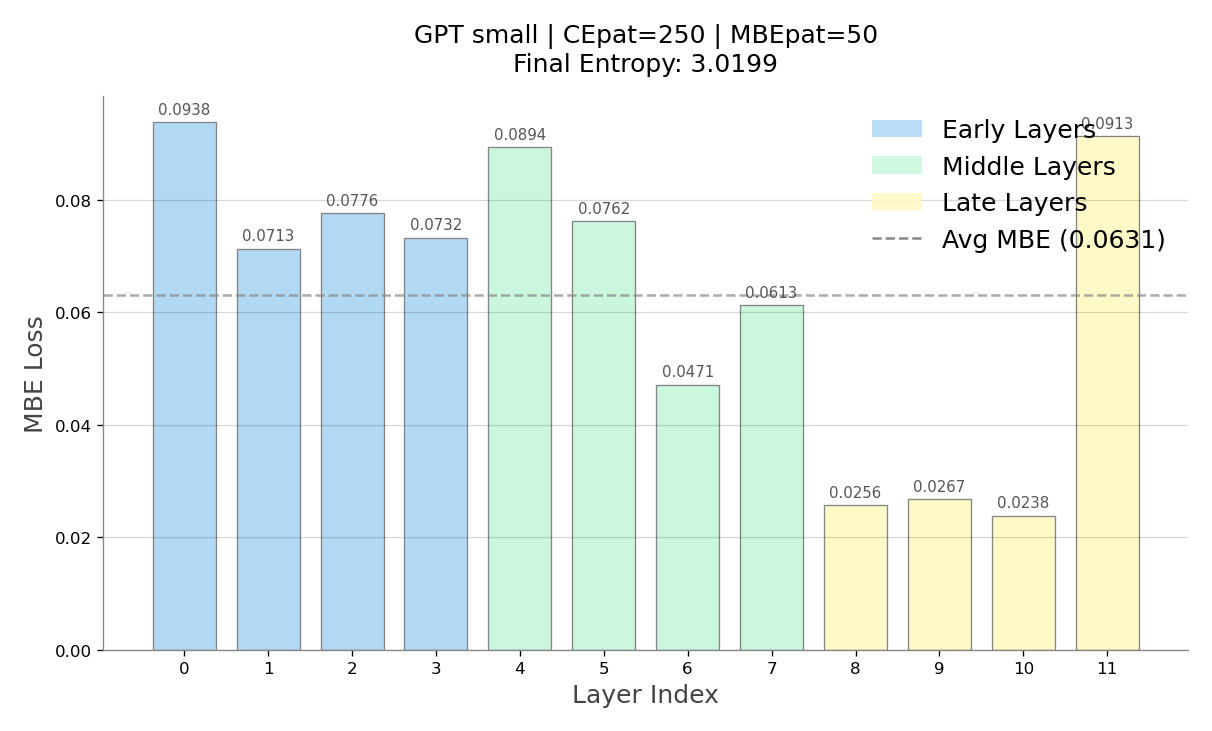

In [ ]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/iblm-run3.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
run_info = "GPT small | CEpat=250 | MBEpat=50" # error run, overwrite config

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info)